## Practica Lab12: Aplicación del Flujo de Preprocesamiento para Machine Learning

## Dataset: Adult Income

**Download latest version**

path = kagglehub.dataset_download("uciml/adult-census-income")

---

## Objetivo

Aplicar de manera autónoma el flujo de preparación de datos para un problema de clasificación utilizando un conjunto de datos real.

Al finalizar la práctica, el estudiante será capaz de:

1. Importación de librerías
2. Carga del dataset
3. Comprensión del problema
4. Exploración inicial (EDA)
5. Correlación e hipótesis
6. Variables predictoras y objetivo
7. Tratamiento de nulos
8. One-Hot Encoding
9. Train/Test Split
10. StandardScaler
11. Árbol de Decisión
12. Predicciones
13. Accuracy
14. Feature Importance
15. Conclusiones

---

# Contexto del Problema

Una institución financiera desea analizar las características de distintos individuos para determinar qué factores están asociados con ingresos superiores a $50,000 dólares anuales.

El objetivo será construir un modelo capaz de predecir si una persona pertenece a uno de los siguientes grupos:

- (<=) 50K
- (>) 50K


## Preguntas

1. ¿Cuál es la variable objetivo?
2. ¿Qué representa dicha variable?
3. ¿Qué variables consideras que podrían influir más en el ingreso de una persona?
4. ¿Cuántas variables predictoras existen?
5. ¿Por qué fue necesario transformar variables categóricas?
7. ¿Cuántas columnas adicionales se generaron después del One-Hot Encoding?
8. ¿Existen valores nulos?
9. ¿Qué variables son numéricas?
10. ¿Qué variables son categóricas?
11. ¿Cuántos registros quedaron en entrenamiento?
12. ¿Cuántos registros quedaron en prueba?
13. ¿Por qué no debemos entrenar utilizando todos los datos?
14. ¿Cuál fue el Accuracy obtenido?
15. ¿Consideras que el resultado es adecuado?
16. ¿Qué factores podrían afectar el desempeño del modelo?
18. ¿Cuál fue la variable más importante?
19. ¿Cuál fue la menos importante?
20. ¿Coinciden los resultados con tus hipótesis iniciales?
21. ¿Qué variables aportan más información al modelo?


# Entregables

El repositorio deberá contener:

```text
Notebooks/
└── Laboratorio12.ipynb
```

---


## Parte 1. Importación de librerías

In [1]:
# Importamos librerias
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt

import kagglehub

/home/rivera/Documentos/ECBD-JoseAngelLopezRivera/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Parte 2. Carga del dataset

In [2]:
path = kagglehub.dataset_download("uciml/adult-census-income")
print("Ruta del dataset descargado:", path)

Ruta del dataset descargado: /home/rivera/.cache/kagglehub/datasets/uciml/adult-census-income/versions/3


In [3]:
dfAdult = pd.read_csv(path + "/adult.csv")
dfAdult.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## Comprensión del problema
Determinar si una persona gana más de $50,000 dólares anuales, con base en sus características demográficas y laborales.

income
0 - Ingreso menor o igual a 50K
1 - Ingreso mayor a 50K

La columna llega como texto ("<=50K", ">50K"), por lo que la convertimos a valores numéricos.

In [4]:
dfAdult["income"] = dfAdult["income"].map({"<=50K": 0, ">50K": 1})
dfAdult["income"].value_counts()

income
0    24720
1     7841
Name: count, dtype: int64

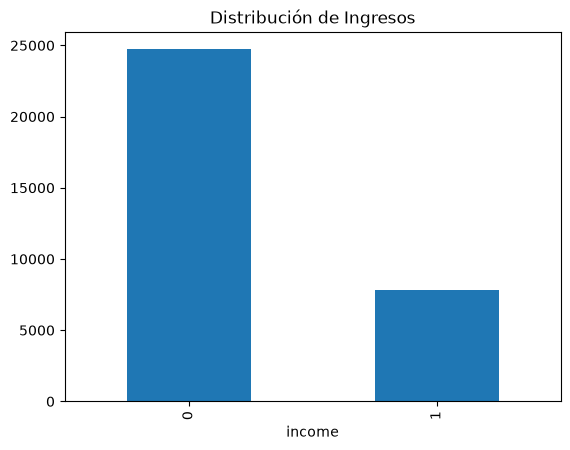

In [5]:
#Graficamos
dfAdult["income"].value_counts().plot(kind='bar')
plt.title("Distribución de Ingresos")
plt.show()

## Parte 3. Exploración Inicial

In [6]:
dfAdult.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456,0.240810
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429,0.427581
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000,0.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000,1.000000


In [7]:
# Hipotesis inicial
dfAdult.groupby(
    "sex"
)["income"].mean()

sex
Female    0.109461
Male      0.305737
Name: income, dtype: float64

In [8]:
dfAdult.groupby(
    "marital.status"
)["income"].mean()

marital.status
Divorced                 0.104209
Married-AF-spouse        0.434783
Married-civ-spouse       0.446848
Married-spouse-absent    0.081340
Never-married            0.045961
Separated                0.064390
Widowed                  0.085599
Name: income, dtype: float64

In [9]:
dfAdult.groupby(
    "education"
)["income"].mean().sort_values(ascending=False)

education
Doctorate       0.740920
Prof-school     0.734375
Masters         0.556587
Bachelors       0.414753
Assoc-voc       0.261216
Assoc-acdm      0.248360
Some-college    0.190235
HS-grad         0.159509
12th            0.076212
10th            0.066452
7th-8th         0.061920
9th             0.052529
11th            0.051064
5th-6th         0.048048
1st-4th         0.035714
Preschool       0.000000
Name: income, dtype: float64

## Parte 4. Correlación e Hipótesis
Creamos una matriz de correlación para identificar la relación lineal
entre las variables numéricas. No identifica la importancia de variables en el modelo

In [10]:
variables_numericas = [
    "income",
    "age",
    "education.num",
    "capital.gain",
    "capital.loss",
    "hours.per.week"
]

In [11]:
corr = dfAdult[variables_numericas].corr()

In [12]:
corr

,income,age,education.num,capital.gain,capital.loss,hours.per.week
income,1.000000,0.234037,0.335154,0.223329,0.150526,0.229689
age,0.234037,1.000000,0.036527,0.077674,0.057775,0.068756
education.num,0.335154,0.036527,1.000000,0.122630,0.079923,0.148123
capital.gain,0.223329,0.077674,0.122630,1.000000,-0.031615,0.078409
capital.loss,0.150526,0.057775,0.079923,-0.031615,1.000000,0.054256
hours.per.week,0.229689,0.068756,0.148123,0.078409,0.054256,1.000000


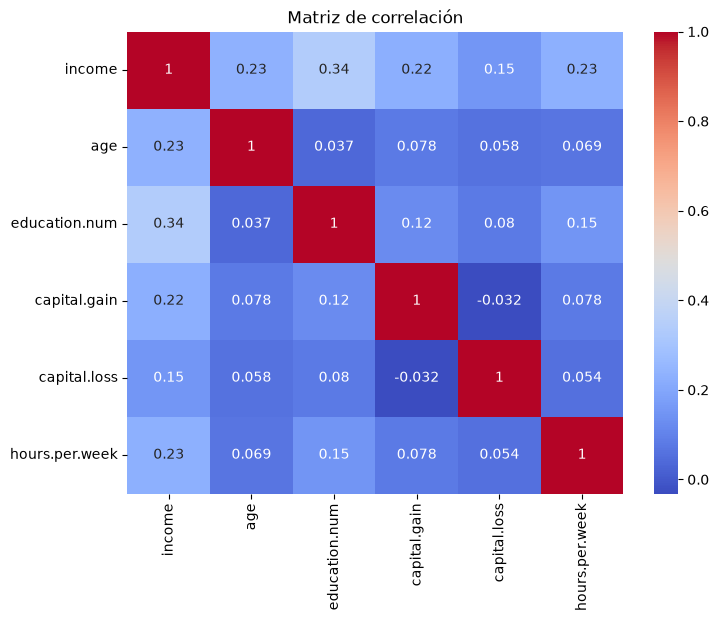

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

## Parte 5. Selección de variables Predictoras y Variable Objetivo

X - Variables que utilizara el modelo
Y - Variable que queremos predecir

No incluimos "fnlwgt" (es un peso estadístico del censo, no una característica de la persona) ni "education" (ya está representada de forma numérica en "education.num"), para evitar columnas redundantes o sin valor predictivo.

In [14]:
columnas = [
    "age",
    "workclass",
    "education.num",
    "marital.status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital.gain",
    "capital.loss",
    "hours.per.week",
    "native.country"
]

In [15]:
#Definimos x y
X = dfAdult[columnas].copy()
Y = dfAdult["income"]

In [16]:
print(X.columns.tolist())

['age', 'workclass', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country']


In [17]:
print(Y.name)

income


# Parte 6. Tratamiento de los valores nulos

Este dataset no usa NaN para los datos faltantes, sino el símbolo "?". Lo reemplazamos por NaN para poder detectarlo e imputarlo igual que cualquier otro valor nulo.

In [18]:
# Reemplazamos "?" por NaN para poder detectar los nulos
X["workclass"] = X["workclass"].replace("?", np.nan)
X["occupation"] = X["occupation"].replace("?", np.nan)
X["native.country"] = X["native.country"].replace("?", np.nan)

In [19]:
# Revisamos las variables predictoras
X.isnull().sum()

age                  0
workclass         1836
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
dtype: int64

In [20]:
X["workclass"] = X["workclass"].fillna(X["workclass"].mode()[0])
X["occupation"] = X["occupation"].fillna(X["occupation"].mode()[0])
X["native.country"] = X["native.country"].fillna(X["native.country"].mode()[0])

In [21]:
# Revisamos las variables predictoras
X.isnull().sum()

age               0
workclass         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
dtype: int64

In [22]:
X.head()

,age,workclass,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
0,90,Private,9,Widowed,Prof-specialty,Not-in-family,White,Female,0,4356,40,United-States
1,82,Private,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States
2,66,Private,10,Widowed,Prof-specialty,Unmarried,Black,Female,0,4356,40,United-States
3,54,Private,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States
4,41,Private,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States


## Parte 7. Codificación de variables categóricas (One-Hot Encoding)
Los algoritmos no entienden texto. Se deben convertir las variables categóricas en variables numéricas.

In [23]:
columnas_categoricas = [
    "workclass",
    "marital.status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native.country"
]

In [24]:
columnas_antes_encoding = X.shape[1]

In [25]:
X = pd.get_dummies(X, columns=columnas_categoricas, drop_first=True)

In [26]:
print("Columnas antes del One-Hot Encoding:", columnas_antes_encoding)
print("Columnas despues del One-Hot Encoding:", X.shape[1])
print("Columnas generadas:", X.shape[1] - columnas_antes_encoding)

Columnas antes del One-Hot Encoding: 12
Columnas despues del One-Hot Encoding: 81
Columnas generadas: 69


In [27]:
X.head()

,age,education.num,capital.gain,capital.loss,hours.per.week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,90,9,0,4356,40,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
1,82,9,0,4356,18,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
2,66,10,0,4356,40,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,54,4,0,3900,40,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
4,41,10,0,3900,40,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False


# Parte 8. Particionamos los datos
No debemos entrenar y evaluar utilizando los mismos datos.

La recomendación es:

Entrenamiento 80% Pruebas 20%

In [28]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [29]:
print("Entrenamiento: ", X_train.shape)

Entrenamiento:  (26048, 81)


In [30]:
print("Prueba:", X_test.shape)

Prueba: (6513, 81)


## Parte 9: Escalado de las variables
Las variables numéricas tienen valores muy distintos entre sí (por ejemplo, "age" frente a "capital.gain"). El escalado evita que las variables con valores mayores dominen el aprendizaje del modelo. En este caso, se escalarán: age, education.num, capital.gain, capital.loss y hours.per.week.

In [31]:
columnas_numericas = [
    "age",
    "education.num",
    "capital.gain",
    "capital.loss",
    "hours.per.week"
]

In [32]:
X_train[columnas_numericas].describe()

,age,education.num,capital.gain,capital.loss,hours.per.week
count,26048.000000,26048.000000,26048.000000,26048.000000,26048.000000
mean,38.526912,10.088337,1106.465602,88.550561,40.518965
std,13.587602,2.580718,7518.611442,406.801027,12.332662
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,47.000000,13.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


In [33]:
scaler = StandardScaler()
X_train[columnas_numericas] = scaler.fit_transform(X_train[columnas_numericas])
X_test[columnas_numericas] = scaler.transform(X_test[columnas_numericas])

In [34]:
X_train[columnas_numericas].describe()

,age,education.num,capital.gain,capital.loss,hours.per.week
count,2.604800e+04,2.604800e+04,2.604800e+04,2.604800e+04,2.604800e+04
mean,-1.753989e-16,1.421195e-16,-2.291369e-17,-4.146287e-17,8.729026e-18
std,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00
min,-1.584336e+00,-3.521699e+00,-1.471664e-01,-2.176795e-01,-3.204476e+00
25%,-7.747588e-01,-4.217268e-01,-1.471664e-01,-2.176795e-01,-4.208134e-02
50%,-1.123775e-01,-3.423025e-02,-1.471664e-01,-2.176795e-01,-4.208134e-02
75%,6.236017e-01,1.128259e+00,-1.471664e-01,-2.176795e-01,3.633539e-01
max,3.788312e+00,2.290749e+00,1.315328e+01,1.049046e+01,4.742055e+00


## Parte 10. Entrenamiento de los datos
Usaremos un arbol de decisión para clasificar registros

In [35]:
modelo = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

In [36]:
modelo.fit(X_train, Y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

## Parte 11. Evaluamos el modelo

Realizar predicciones sobre el conjunto de prueba y calcular la precisión del modelo

In [37]:
predicciones = modelo.predict(
    X_test
)

In [38]:
pd.DataFrame({
    "Real ": Y_test,
    "Predicción:": predicciones
}).head(10)

,Real,Predicción:
14160,0,0
27048,0,0
28868,0,0
5667,0,0
7827,0,0
15382,0,0
4641,0,0
8943,0,0
216,0,0
5121,0,0


# Parte 12. Evaluación del modelo
El accuracy determina el porcentaje de predicciones correctas realizadas por el modelo

In [39]:
accuaracy = accuracy_score(Y_test, predicciones)

In [40]:
print(f"Accuracy del modelo: {accuaracy:.4f}")

Accuracy del modelo: 0.8449


# Parte 13. Importancia de las variables
Analizar las variables más relevantes para el algoritmo, al realizar las predicciones

In [41]:
importancias = pd.DataFrame({
    "Variable" : X_train.columns,
    "Importancia": modelo.feature_importances_ #Que variables es importante para el modelo
})

In [42]:
importancias.sort_values(by="Importancia", ascending=False)

,Variable,Importancia
13,marital.status_Married-civ-spouse,0.491711
1,education.num,0.248303
2,capital.gain,0.226773
3,capital.loss,0.021811
0,age,0.011235
...,...,...
76,native.country_Thailand,0.000000
77,native.country_Trinadad&Tobago,0.000000
78,native.country_United-States,0.000000
79,native.country_Vietnam,0.000000


# Parte 14. Conclusiones

**1. ¿Cuál es la variable objetivo?**
`income`.

**2. ¿Qué representa dicha variable?**
Si una persona gana más de $50,000 dólares anuales (1 = `>50K`) o no (0 = `<=50K`).

**3. ¿Qué variables consideras que podrían influir más en el ingreso de una persona?**
A priori: nivel educativo (`education.num`), estado civil (`marital.status`), horas trabajadas por semana (`hours.per.week`) y la ganancia de capital (`capital.gain`). Esta hipótesis se confirma en la matriz de correlación y en la importancia de variables del modelo.

**4. ¿Cuántas variables predictoras existen?**
12 variables originales (antes del One-Hot Encoding): `age`, `workclass`, `education.num`, `marital.status`, `occupation`, `relationship`, `race`, `sex`, `capital.gain`, `capital.loss`, `hours.per.week`, `native.country`.

**5. ¿Por qué fue necesario transformar variables categóricas?**
Porque los algoritmos de Machine Learning (como el árbol de decisión usado aquí) trabajan con valores numéricos, no con texto. El One-Hot Encoding convierte cada categoría en una columna binaria (0/1) sin imponer un orden artificial entre ellas.

**6. ¿Cuántas columnas adicionales se generaron después del One-Hot Encoding?**
Se pasó de 12 a 81 columnas, es decir, se generaron 69 columnas adicionales (`drop_first=True` para evitar redundancia/multicolinealidad).

**7. ¿Existen valores nulos?**
No como `NaN`, pero el dataset usa el símbolo `"?"` como marcador de valor faltante en `workclass` (1836 registros), `occupation` (1843 registros) y `native.country` (583 registros). Se reemplazaron por `NaN` y se imputaron con la moda de cada columna.

**8. ¿Qué variables son numéricas?**
`age`, `fnlwgt`, `education.num`, `capital.gain`, `capital.loss`, `hours.per.week` (de estas, se usaron todas excepto `fnlwgt`, que se descartó por no ser una característica de la persona sino un peso de muestreo del censo).

**9. ¿Qué variables son categóricas?**
`workclass`, `education`, `marital.status`, `occupation`, `relationship`, `race`, `sex`, `native.country` (se descartó `education` por ser redundante con `education.num`).

**10. ¿Cuántos registros quedaron en entrenamiento?**
26,048 registros (80% del total).

**11. ¿Cuántos registros quedaron en prueba?**
6,513 registros (20% del total).

**12. ¿Por qué no debemos entrenar utilizando todos los datos?**
Porque necesitamos datos que el modelo no haya visto durante el entrenamiento para evaluar su capacidad real de generalización. Si se evalúa con los mismos datos de entrenamiento, el accuracy estaría inflado y no reflejaría el desempeño ante datos nuevos.

**13. ¿Cuál fue el Accuracy obtenido?**
≈ 0.8449 (84.49%).

**14. ¿Consideras que el resultado es adecuado?**
Es un resultado razonable para un primer modelo simple (árbol con `max_depth=4`), especialmente considerando que la clase `>50K` es minoritaria (~24% de los registros). Sin embargo, el accuracy por sí solo puede ser engañoso en datasets desbalanceados: un modelo que siempre prediga `<=50K` ya acertaría ~76% de las veces, por lo que conviene complementar con métricas como precision, recall o F1 antes de considerarlo "bueno".

**15. ¿Qué factores podrían afectar el desempeño del modelo?**
El desbalance de clases, la profundidad limitada del árbol (`max_depth=4`), la imputación simple por moda en variables con muchos nulos (`occupation`, `workclass`), y la alta cardinalidad de `native.country` (genera muchas columnas dispersas tras el One-Hot Encoding).

**16. ¿Cuál fue la variable más importante?**
`marital.status_Married-civ-spouse` (estar casado/a con cónyuge civil), seguida de `education.num` y `capital.gain`.

**17. ¿Cuál fue la menos importante?**
La mayoría de las columnas generadas por el One-Hot Encoding de `workclass`, `occupation`, `race` y `native.country` tienen importancia 0 o cercana a 0: el árbol, al tener solo profundidad 4, no llega a usarlas.

**18. ¿Coinciden los resultados con tus hipótesis iniciales?**
Parcialmente. Se esperaba que `education.num` y `hours.per.week` fueran las variables más influyentes, y `education.num` efectivamente aparece entre las más importantes. Sin embargo, el estado civil (`marital.status`) resultó ser la variable más relevante para el modelo, algo que no era evidente solo con la matriz de correlación (que solo mide relaciones lineales entre variables numéricas).

**19. ¿Qué variables aportan más información al modelo?**
`marital.status_Married-civ-spouse`, `education.num` y `capital.gain` concentran la mayor parte de la importancia total del modelo.